<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [53]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [54]:
import pandas as pd


Import matplotlib


In [55]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [56]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [57]:
## Write your code here
duplicates = df[(df.duplicated())] # pandas df method that returns T/F for whether record is unique
print(duplicates.head(3))

       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to open-source projects;Other...   

                                               EdLevel  \
65437                        Primary/elementary school   
65438     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
65439  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   

                                    

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [58]:
## Write your code here
patterns = ['MainBranch', 'Employment', 'RemoteWork'] # identify columns for analysis

# store duplicate all records that have a column pattern match in variable duplicate_patterns
duplicate_patterns = df[df.duplicated(subset=patterns, keep=False)] 

print(duplicate_patterns)

       ResponseId                                         MainBranch  \
0               1                     I am a developer by profession   
1               2                     I am a developer by profession   
2               3                     I am a developer by profession   
3               4                              I am learning to code   
4               5                     I am a developer by profession   
...           ...                                                ...   
65452       35588  I am not primarily a developer, but I write co...   
65453       50580                     I am a developer by profession   
65454        9938                     I am a developer by profession   
65455       40874                     I am a developer by profession   
65456       36796                     I am a developer by profession   

                      Age                                         Employment  \
0      Under 18 years old                              

In [59]:
duplicate_patterns.shape # shows the rows and columns of duplicate_patterns

(65290, 114)

In [60]:
duplicates.shape # shows the rows and columns of exact duplicates

(20, 114)

In [61]:
pattern_counts = ( # group patterns
    df.groupby(patterns)
        .size() # count the number of each pattern
        .reset_index(name='RespondentCount') # create an index Respondent Count
        .sort_values('RespondentCount', ascending=False) # sort from highest to lowest count
)

print(pattern_counts)

                                            MainBranch  \
0                       I am a developer by profession   
2                       I am a developer by profession   
1                       I am a developer by profession   
78                      I am a developer by profession   
8                       I am a developer by profession   
..                                                 ...   
405  I used to be a developer by profession, but no...   
407  I used to be a developer by profession, but no...   
408  I used to be a developer by profession, but no...   
409  I used to be a developer by profession, but no...   
413  I used to be a developer by profession, but no...   

                                            Employment  \
0                                  Employed, full-time   
2                                  Employed, full-time   
1                                  Employed, full-time   
78   Independent contractor, freelancer, or self-em...   
8    Employed

In [21]:
pattern_groups = df.groupby(patterns) # groupby patterns

column_similarity = pattern_groups.nunique() # pandas method that is counts unique records
print(column_similarity.T.head(3))

MainBranch       I am a developer by profession                   \
Employment                  Employed, full-time                    
RemoteWork Hybrid (some remote, some in-person) In-person Remote   
ResponseId                                15286      7118  12191   
Age                                           8         8      8   
Check                                         1         1      1   

MainBranch                                                           \
Employment Employed, full-time;Employed, part-time                    
RemoteWork    Hybrid (some remote, some in-person) In-person Remote   
ResponseId                                      78        25     87   
Age                                              5         2      6   
Check                                            1         1      1   

MainBranch                                                                           \
Employment Employed, full-time;Independent contractor, freelancer, or self-em

In [62]:
# For each column, count how many response patterns have the same value for all rows,
# then sort columns so the ones that are most often identical come first
similar_columns = (column_similarity == 1).sum().sort_values(ascending=False)

print(similar_columns)

Check                         449
SOAccount                     193
AISelect                      191
AIThreat                      179
SurveyLength                  176
                             ... 
YearsCodePro                   63
TechEndorse                    63
AINextMuch less integrated     61
CompTotal                      55
ConvertedCompYearly            51
Length: 111, dtype: int64


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


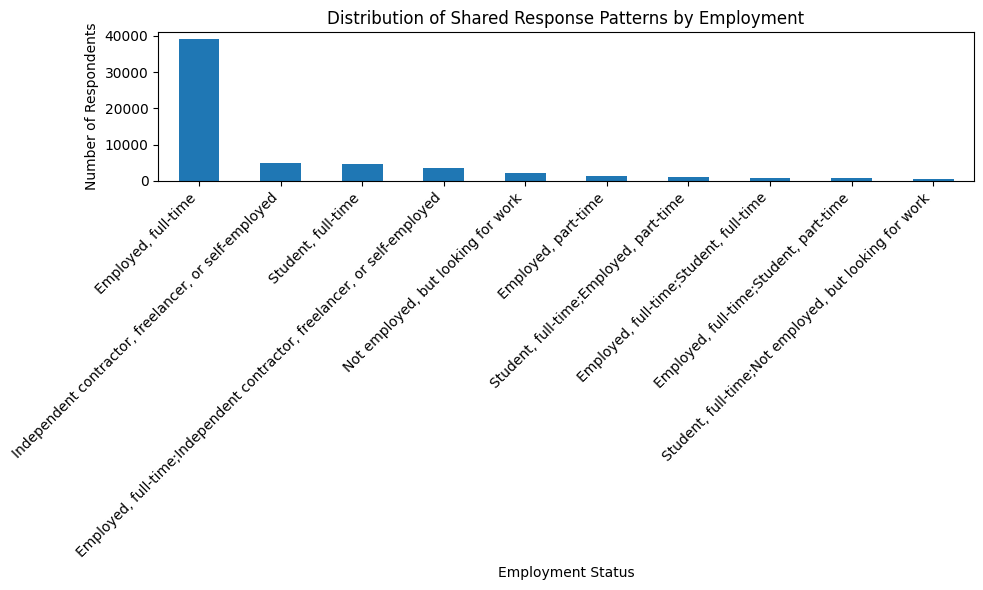

In [63]:
## Write your code here
import matplotlib.pyplot as plt

employment_counts = duplicate_patterns['Employment'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,6))

bars = employment_counts.plot(kind='bar', ax=ax)

# Rotate and align the x-axis labels properly
ax.set_xticklabels(employment_counts.index, rotation=45, ha='right')

ax.set_title('Distribution of Shared Response Patterns by Employment')
ax.set_xlabel('Employment Status')
ax.set_ylabel('Number of Respondents')

plt.tight_layout()  # ensures labels fit
plt.show()

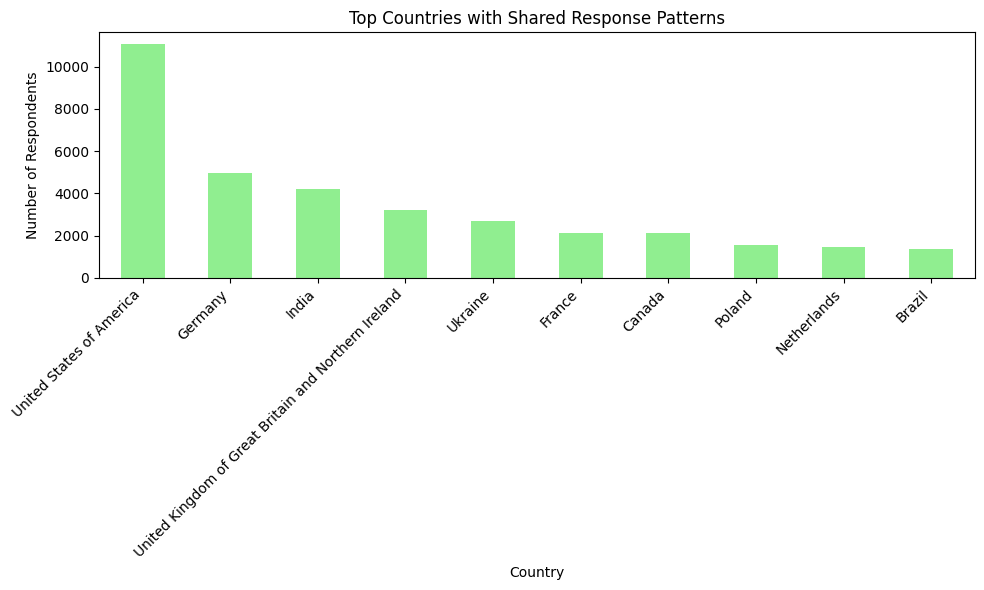

In [64]:
import matplotlib.pyplot as plt

# Take top 10 countries
country_counts = duplicate_patterns['Country'].value_counts().head(10)

# Create figure and axes
fig, ax = plt.subplots(figsize=(10,6))

# Plot the bar chart
country_counts.plot(kind='bar', ax=ax, color='lightgreen')

# Set x-axis labels, rotate and align
ax.set_xticklabels(country_counts.index, rotation=45, ha='right')

# Add titles and labels
ax.set_title('Top Countries with Shared Response Patterns')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Respondents')

# Adjust layout so labels aren't cut off
plt.tight_layout()

plt.show()

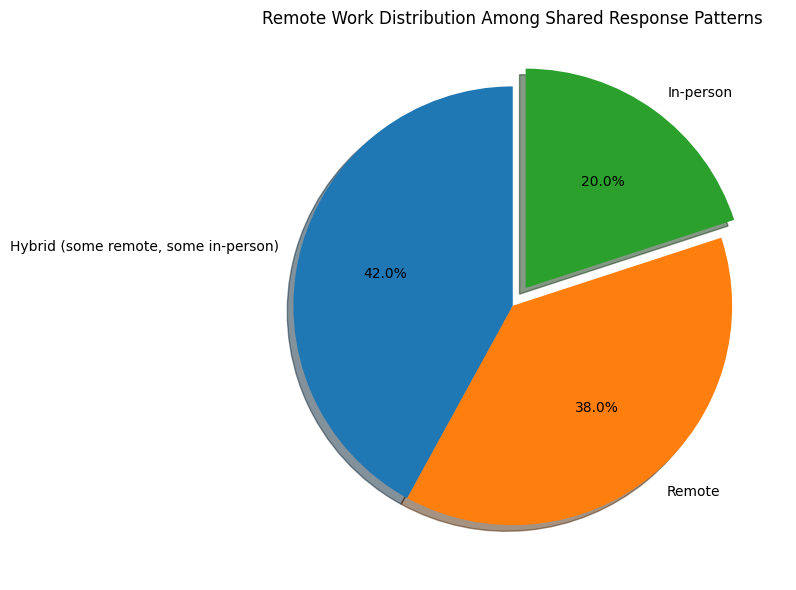

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Count remote work types
remote_counts = duplicate_patterns['RemoteWork'].value_counts()

# Identify the smallest slice to explode
explode = [0.1 if v == remote_counts.min() else 0 for v in remote_counts]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8,8))

# Plot pie chart
remote_counts.plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True
)

# Set title and remove ylabel
ax.set_title('Remote Work Distribution Among Shared Response Patterns')
ax.set_ylabel('')  # remove default ylabel

plt.tight_layout()
plt.show()

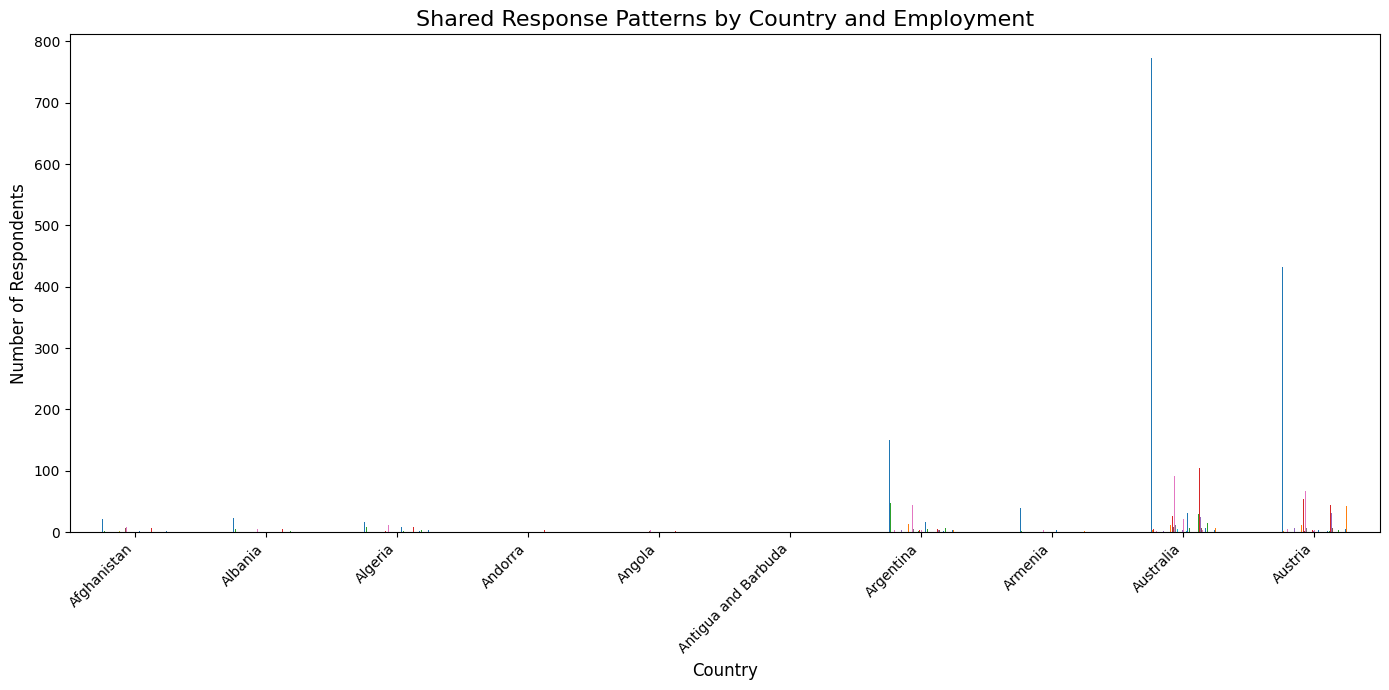

In [67]:
import matplotlib.pyplot as plt

# Group and select top 10 countries
grouped = duplicate_patterns.groupby(['Country','Employment']).size().unstack()
grouped_top = grouped.head(10)

# Create a bigger figure
fig, ax = plt.subplots(figsize=(14,7))

# Plot grouped bar chart WITHOUT legend
grouped_top.plot(kind='bar', ax=ax, legend=False)

# Set title and axis labels
ax.set_title('Shared Response Patterns by Country and Employment', fontsize=16)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)

# Rotate x-axis labels and align
ax.set_xticklabels(grouped_top.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

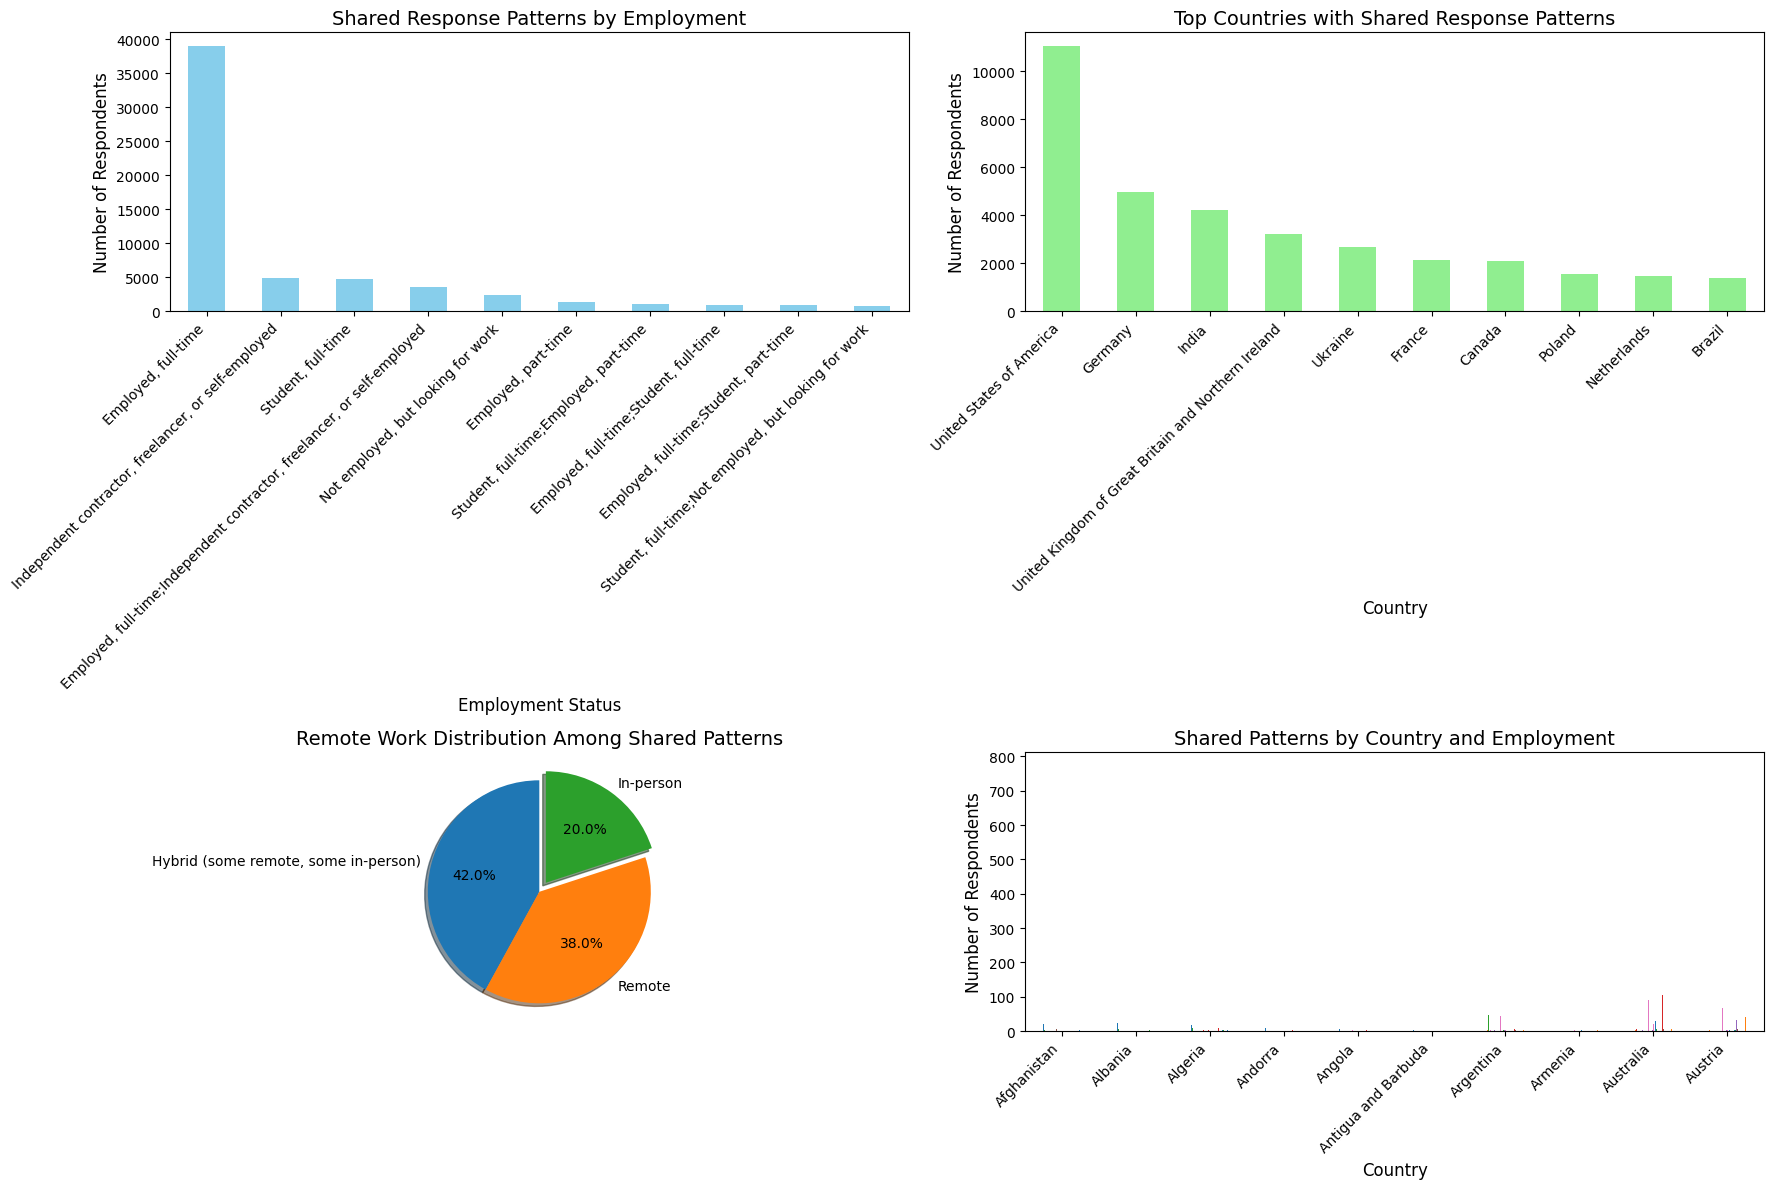

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Prepare data
employment_counts = duplicate_patterns['Employment'].value_counts().head(10)
country_counts = duplicate_patterns['Country'].value_counts().head(10)
remote_counts = duplicate_patterns['RemoteWork'].value_counts()
grouped = duplicate_patterns.groupby(['Country','Employment']).size().unstack()
grouped_top = grouped.head(10)

# Explode smallest slice for pie chart
explode = [0.1 if v == remote_counts.min() else 0 for v in remote_counts]

# -------------------------------
# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))  # larger figure for readability

# -------------------------------
# 1. Employment bar chart
ax = axes[0,0]
employment_counts.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Shared Response Patterns by Employment', fontsize=14)
ax.set_xlabel('Employment Status', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_xticklabels(employment_counts.index, rotation=45, ha='right')

# -------------------------------
# 2. Top Countries bar chart
ax = axes[0,1]
country_counts.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Top Countries with Shared Response Patterns', fontsize=14)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_xticklabels(country_counts.index, rotation=45, ha='right')

# -------------------------------
# 3. RemoteWork pie chart
ax = axes[1,0]
remote_counts.plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True
)
ax.set_title('Remote Work Distribution Among Shared Patterns', fontsize=14)
ax.set_ylabel('')  # remove default ylabel

# -------------------------------
# 4. Grouped Country x Employment bar chart
ax = axes[1,1]
grouped_top.plot(kind='bar', ax=ax, legend=False)
ax.set_title('Shared Patterns by Country and Employment', fontsize=14)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_xticklabels(grouped_top.index, rotation=45, ha='right')

# -------------------------------
plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [69]:
duplicates.shape[0] # this tells us the number of unique records that are exact duplicates

20

In [71]:
duplicate_patterns.shape[0] # this tells the number of duplicates that share a pattern

65290

In [72]:
df_unique = df.drop_duplicates()

df_unique.shape[0]

65437

In [73]:
df_unique_pattern = df.drop_duplicates(subset=['MainBranch','Employment','RemoteWork'])

df_unique_pattern.shape[0]

561

In [75]:
# Total rows in the original dataframe
total_rows = df.shape[0]

# Total rows after removing duplicates based on a subset
subset_rows = df_unique_pattern.shape[0]

# Calculate percentage retained
percent_retained = (subset_rows / total_rows) * 100

print(f"Rows retained after subset-based uniqueness: {subset_rows} / {total_rows} ({percent_retained:.2f}%)")

Rows retained after subset-based uniqueness: 561 / 65457 (0.86%)


As you can tell removing duplicate patterns leaves less than 1% of total unique responses so I would suggest not removing subset matching patterns. There is still useful analysis that can be obtained from purely unique responses but an analysis of those responses would not accurately represent the data. 

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
